In [49]:
!pip -q install shap captum scikit-learn pandas numpy matplotlib seaborn openml


In [50]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from captum.attr import IntegratedGradients
from scipy.stats import spearmanr
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score

In [51]:
#set seed for result reproduceability
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(device)


In [52]:
#load data
data = fetch_openml(name="credit-g", version=1, as_frame=True)
X = data.data.copy() #independent variables
y = data.target.copy() # target variable

y = (y == "bad").astype(int) #converting target variable to 0/1: "bad" -> True -> 1, anything else ("good") -> False -> 0



In [53]:
#overview of data

print(X.shape)
print(X.head())
print(y.value_counts())

(1000, 20)
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     personal_status other_parties  residence_since  \
0                       4         male single          none                4   
1                       2  fe

In [54]:
#defining neural network
class CreditNet(nn.Module):
    def __init__(self, input_size):
        super(CreditNet, self).__init__()
        #1st layer: input size -> 128 neurons
        self.fc1 = nn.Linear(input_size, 128)
        #ReLU activation function
        self.relu = nn.ReLU()
        #2nd layer: 128 -> 64 neurons
        self.fc2 = nn.Linear(128, 64)
        #3rd layer: 64 -> 1 neuron (for binary classification)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        #pass input through the 1st layer and ReLU activation
        out = self.fc1(x)
        out = self.relu(out)
        #pass through 2nd layer and ReLU activation
        out = self.fc2(out)
        out = self.relu(out)
        #pass through final output layer
        out = self.fc3(out)
        return out


In [55]:
#k-fold-cross-validation algorithm that divides data into 10 splits/folds.
#Model is trained k(=10) times and each fold is used for validation once, while all others are used for training

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
# by using StratifiedKFold, I make sure the split of targets is roughly the same as in our original data (so ca. 70/30)


#(initially empty) lists to store results from each iteration
fold_accuracies = []
fold_roc_aucs = []
all_shap_values = []
all_ig_attributions = []

#params that set the size for how many samples to use in SHAP/IG explanations
background_size = 100 #nr of samples from training as baseline
explain_size = 100 #nr of samples from validation

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}/10")

    #1)Split data for each current fold
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]



    #2)Preprocessing

    #avoiding data leakage by redefineing and refitting preprocessor steps
    categorical_cols = X_train_fold.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X_train_fold.select_dtypes(exclude=["object", "category"]).columns.tolist()


    #numerical features
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")), #replaces missing vals with median
        ("scaler", StandardScaler()) #scales features to mean 0 and std 1
    ])

    #categorical features
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), #replaces missing vals with most frequent val (because categorical doesn't have a mean)
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) #converts cat. into new binary feature
    ])

    #applies transformer to numerical and categorical columns
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    X_train_proc_fold = preprocessor_fold.fit_transform(X_train_fold)
    X_val_proc_fold = preprocessor_fold.transform(X_val_fold)

    #retrieve feature names after one-hot encoding
    feature_names = preprocessor_fold.get_feature_names_out()
    feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

    #Converting to tensosr
    X_train_tensor_fold = torch.tensor(X_train_proc_fold, dtype=torch.float32).to(device)
    X_val_tensor_fold = torch.tensor(X_val_proc_fold, dtype=torch.float32).to(device)
    y_train_tensor_fold = torch.tensor(y_train_fold.values, dtype=torch.float32).view(-1, 1).to(device)
    y_val_tensor_fold = torch.tensor(y_val_fold.values, dtype=torch.float32).view(-1, 1).to(device)





    #3)Model Definition and Training
    model = CreditNet(X_train_proc_fold.shape[1]).to(device) # Instantiate a new model for each fold
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 1000
    batch_size = 64

    #training
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(X_train_tensor_fold.size(0))
        for i in range(0, X_train_tensor_fold.size(0), batch_size):
            idx = perm[i:i+batch_size]
            xb = X_train_tensor_fold[idx]
            yb = y_train_tensor_fold[idx]

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()





    #4)model evaluation for each fold
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_tensor_fold) #predictions on test set
        val_probs = torch.sigmoid(val_logits).cpu().numpy().ravel() #sigmoid activation function for probs between 0 and 1
        val_preds = (val_probs >= 0.5).astype(int) #converts float probabilitys into binary predictions

    fold_accuracy = accuracy_score(y_val_fold, val_preds)
    fold_roc_auc = roc_auc_score(y_val_fold, val_probs)
    fold_accuracies.append(fold_accuracy)
    fold_roc_aucs.append(fold_roc_auc)

    print(f"Fold {fold + 1} Accuracy: {fold_accuracy:.3f}, ROC AUC: {fold_roc_auc:.3f}")

    #5)SHAP Explanations for each fold

    #Select 100 samples for background/explanations from the fold data
    background_idx_fold = np.random.choice(len(X_train_proc_fold), background_size, replace=False)
    explain_idx_fold = np.random.choice(len(X_val_proc_fold), explain_size, replace=False)

    #extract actual data points that correspond to the selected indexes
    background_data_fold = X_train_proc_fold[background_idx_fold]
    X_explain_fold = X_val_proc_fold[explain_idx_fold]

    #convert numpy array to pytorch tensors
    background_tensor_fold = torch.tensor(background_data_fold, dtype=torch.float32).to(device)
    X_explain_tensor_fold = torch.tensor(X_explain_fold, dtype=torch.float32).to(device)

    #SHAP GradientExplainer
    explainer = shap.GradientExplainer(model, background_tensor_fold)

    #SHAP value calculation
    shap_values_fold = explainer.shap_values(X_explain_tensor_fold)

    if isinstance(shap_values_fold, list):
        shap_values_fold = shap_values_fold[0] #SHAP values for the positive_class
    all_shap_values.append(shap_values_fold)

    #6)Integrated Gradients (IG) explanations for each fold

    #IG explainer loaded
    ig = IntegratedGradients(model)

    #baseline for IG (reference point where all features are neutral)
    baseline_fold = background_tensor_fold.mean(dim=0, keepdim=True)

    ig_attributions_fold = [] #empty list for storage

    #loop through each sample, calculates IG attribution
    #by taking input sample and baseline, returning aditional delta value
    #indicating convergence quality
    for i in range(X_explain_tensor_fold.shape[0]):
        attr, delta = ig.attribute(
            X_explain_tensor_fold[i:i+1],
            baselines=baseline_fold,
            target=None,
            return_convergence_delta=True
        )
        ig_attributions_fold.append(attr.detach().cpu().numpy()[0])
    all_ig_attributions.append(np.array(ig_attributions_fold))


Fold 1/10
Fold 1 Accuracy: 0.690, ROC AUC: 0.744
Fold 2/10
Fold 2 Accuracy: 0.760, ROC AUC: 0.744
Fold 3/10
Fold 3 Accuracy: 0.700, ROC AUC: 0.704
Fold 4/10
Fold 4 Accuracy: 0.700, ROC AUC: 0.681
Fold 5/10
Fold 5 Accuracy: 0.730, ROC AUC: 0.795
Fold 6/10
Fold 6 Accuracy: 0.740, ROC AUC: 0.742
Fold 7/10
Fold 7 Accuracy: 0.780, ROC AUC: 0.799
Fold 8/10
Fold 8 Accuracy: 0.730, ROC AUC: 0.711
Fold 9/10
Fold 9 Accuracy: 0.820, ROC AUC: 0.785
Fold 10/10
Fold 10 Accuracy: 0.700, ROC AUC: 0.778


In [56]:
print("Cross-Validation Results")
print(f"Average Accuracy: {np.mean(fold_accuracies):.3f} +/- {np.std(fold_accuracies):.3f}")
print(f"Average ROC AUC: {np.mean(fold_roc_aucs):.3f} +/- {np.std(fold_roc_aucs):.3f}")

Cross-Validation Results
Average Accuracy: 0.735 +/- 0.040
Average ROC AUC: 0.748 +/- 0.039


In [57]:
#Average SHAP values and IG attributions across folds
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0).flatten() for sv in all_shap_values], axis=0)
mean_abs_ig = np.mean([np.abs(ig_attr).mean(axis=0).flatten() for ig_attr in all_ig_attributions], axis=0)

comparison_df_cv = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
    "mean_abs_ig": mean_abs_ig
})

comparison_df_cv["shap_rank"] = comparison_df_cv["mean_abs_shap"].rank(ascending=False, method="min")
comparison_df_cv["ig_rank"] = comparison_df_cv["mean_abs_ig"].rank(ascending=False, method="min")
comparison_df_cv["rank_diff"] = (comparison_df_cv["shap_rank"] - comparison_df_cv["ig_rank"]).abs()

comparison_df_cv = comparison_df_cv.sort_values("mean_abs_shap", ascending=False)
print("Feature Importance Comparison")
print(comparison_df_cv.head(20))

Feature Importance Comparison
                                          feature  mean_abs_shap  mean_abs_ig  \
10                    checking_status_no checking       3.977034     4.026379   
8                              checking_status_<0       3.306939     3.488231   
0                                        duration       2.951886     2.924789   
2                          installment_commitment       2.875579     3.584856   
12  credit_history_critical/other existing credit       2.783038     2.745195   
3                                 residence_since       2.730619     4.080472   
1                                   credit_amount       2.530687     2.517370   
25                               purpose_used car       2.428283     2.461725   
5                                existing_credits       2.365979     3.394323   
4                                             age       1.859991     2.210536   
32                              employment_4<=X<7       1.679213     1.514473  

In [58]:
#Looking at hand-picked sensitive features
sensitive_keywords = ["personal_status", "sex", "foreign_worker"]

sensitive_df_cv = comparison_df_cv[
    comparison_df_cv["feature"].apply(lambda x: any(k in x for k in sensitive_keywords))
].copy()

sensitive_df_cv = sensitive_df_cv.sort_values("mean_abs_shap", ascending=False)
print("Sensitive Feature Importances (Averaged Across Folds)")
print(sensitive_df_cv)

Sensitive Feature Importances (Averaged Across Folds)
                               feature  mean_abs_shap  mean_abs_ig  shap_rank  \
36  personal_status_female div/dep/mar       1.146043     1.406392       20.0   
39         personal_status_male single       1.109594     1.362177       23.0   
59                   foreign_worker_no       0.882548     0.861421       33.0   
38        personal_status_male mar/wid       0.540408     0.657010       42.0   
37        personal_status_male div/sep       0.423083     0.521356       50.0   
60                  foreign_worker_yes       0.289317     0.277166       56.0   

    ig_rank  rank_diff  
36     20.0        0.0  
39     23.0        0.0  
59     36.0        3.0  
38     44.0        2.0  
37     49.0        1.0  
60     56.0        0.0  


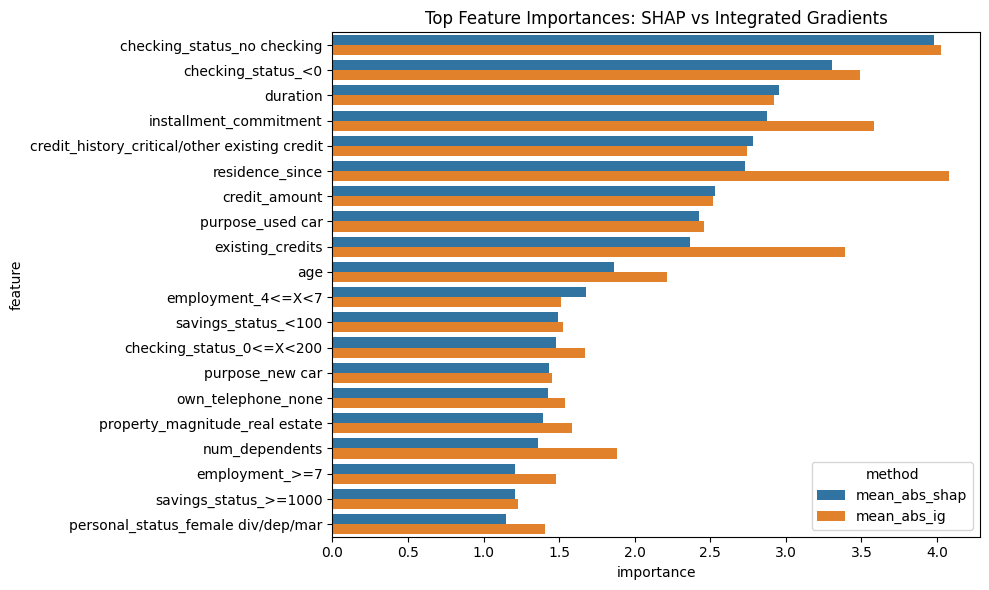

In [59]:
#plot feature importance of top 20 (using SHAP's top 20)
top_n = 20
plot_df_cv = comparison_df_cv.head(top_n).copy()

plot_df_melt_cv = plot_df_cv.melt(
    id_vars="feature",
    value_vars=["mean_abs_shap", "mean_abs_ig"],
    var_name="method",
    value_name="importance"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df_melt_cv, y="feature", x="importance", hue="method")
plt.title("Top Feature Importances: SHAP vs Integrated Gradients")
plt.tight_layout()
plt.show()

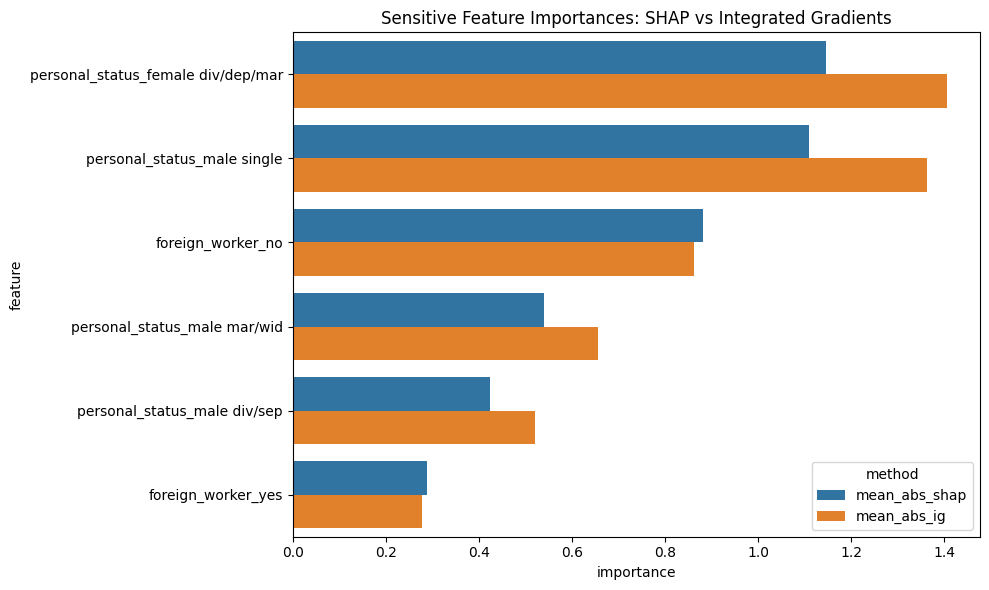

In [60]:
#plot with SHAP/IG comparison for sensitive only
if len(sensitive_df_cv) > 0:
    sensitive_melt_cv = sensitive_df_cv.melt(
        id_vars="feature",
        value_vars=["mean_abs_shap", "mean_abs_ig"],
        var_name="method",
        value_name="importance"
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=sensitive_melt_cv, y="feature", x="importance", hue="method")
    plt.title("Sensitive Feature Importances: SHAP vs Integrated Gradients")
    plt.tight_layout()
    plt.show()

In [61]:
#check method agreements/overlap

corr_cv, pval_cv = spearmanr(comparison_df_cv["mean_abs_shap"], comparison_df_cv["mean_abs_ig"])
print("Agreement between explanation methods")
print(f"Spearman correlation between SHAP and IG importances: {corr_cv:.3f}")
print(f"p-value: {pval_cv:}")

top10_shap_cv = set(comparison_df_cv.sort_values("mean_abs_shap", ascending=False).head(10)["feature"])
top10_ig_cv = set(comparison_df_cv.sort_values("mean_abs_ig", ascending=False).head(10)["feature"])

intersection_cv = top10_shap_cv.intersection(top10_ig_cv) #set of features that are in both SHAP and IG'S TOP 10
print("Top 10 overlap:", len(intersection_cv))
print("Shared features:", intersection_cv)

top15_shap_cv = set(comparison_df_cv.sort_values("mean_abs_shap", ascending=False).head(15)["feature"])
top15_ig_cv = set(comparison_df_cv.sort_values("mean_abs_ig", ascending=False).head(15)["feature"])

intersection_15_cv = top15_shap_cv.intersection(top15_ig_cv) #set of features that are in both SHAP and IG'S TOP 15
print("Top 15 overlap:", len(intersection_15_cv))
print("Shared features:", intersection_15_cv)


top20_shap_cv = set(comparison_df_cv.sort_values("mean_abs_shap", ascending=False).head(20)["feature"])
top20_ig_cv = set(comparison_df_cv.sort_values("mean_abs_ig", ascending=False).head(20)["feature"])

intersection_20_cv = top20_shap_cv.intersection(top20_ig_cv) #set of features that are in both SHAP and IG's TOP 20
print("Top 20 overlap:", len(intersection_20_cv))
print("Shared features:", intersection_20_cv)


Agreement between explanation methods
Spearman correlation between SHAP and IG importances: 0.983
p-value: 1.960199553709115e-45
Top 10 overlap: 10
Shared features: {'credit_history_critical/other existing credit', 'purpose_used car', 'age', 'duration', 'existing_credits', 'installment_commitment', 'checking_status_no checking', 'credit_amount', 'checking_status_<0', 'residence_since'}
Top 15 overlap: 13
Shared features: {'credit_history_critical/other existing credit', 'purpose_used car', 'age', 'duration', 'savings_status_<100', 'existing_credits', 'own_telephone_none', 'installment_commitment', 'checking_status_no checking', 'credit_amount', 'checking_status_<0', 'checking_status_0<=X<200', 'residence_since'}
Top 20 overlap: 19
Shared features: {'duration', 'checking_status_0<=X<200', 'employment_>=7', 'employment_4<=X<7', 'checking_status_no checking', 'num_dependents', 'residence_since', 'purpose_used car', 'age', 'purpose_new car', 'savings_status_<100', 'existing_credits', 'chec